# Coin Detection & Classification

Detect and classify coins in an image using circular Hough transform and relative size features.

In [145]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Hough Circle Detection Settings
HOUGH_DP = 1.2
HOUGH_MIN_DIST = 24
HOUGH_PARAM1 = 50
HOUGH_PARAM2 = 34
HOUGH_MIN_RADIUS = 10
HOUGH_MAX_RADIUS = 100

# Blur Settings
BLUR_KERNEL = (9, 9)
BLUR_SIGMA = 2

# Image Settings
MAX_IMAGE_WIDTH = 800

## Adjust Detection

If detection isn't working well, tweak these parameters in the first code cell:

- **HOUGH_PARAM2**: Lower = more circles detected (try 20-40)
- **HOUGH_PARAM1**: Edge detection threshold (try 40-70)
- **HOUGH_MIN_DIST**: Min distance between coin centers (try 20-50)
- **HOUGH_MIN_RADIUS / MAX_RADIUS**: Coin size range in pixels

## Usage

Run the code below with your coin image path:

In [146]:
def analyze_coins(image_path):
    """Main function: detect and classify coins."""
    print("\nProcessing image...")
    
    try:
        original, gray, blurred = preprocess_image(image_path)
        print(f"Image loaded: {original.shape[1]} x {original.shape[0]} pixels")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return
    
    # Detect coins
    print("Detecting coins...")
    circles = detect_coins(blurred)
    print(f"Found {len(circles)} coin(s)")
    
    if len(circles) == 0:
        print("No coins detected. Try adjusting parameters.")
        return
    
    # Extract features and classify
    print("Classifying coins...")
    coins = extract_features(original, circles)
    
    # Draw results
    result = draw_results(original, coins)
    
    # Print results
    print("\n" + "="*80)
    print("DETECTED COINS")
    print("="*80)
    for coin in coins:
        print(f"\nCoin #{coin['id']}:")
        print(f"  Center:     {coin['center']}")
        print(f"  Radius:     {coin['radius']} px")
        print(f"  Diameter:   {coin['diameter']} px")
        print(f"  Area:       {coin['area']} px²")
        print(f"  Size:       {coin['size']}")
    
    print("\n" + "="*80)
    print(f"Total Coins: {len(coins)}")
    
    # Count by size
    sizes = {}
    for coin in coins:
        size = coin['size']
        sizes[size] = sizes.get(size, 0) + 1
    
    print("\nBy Size:")
    for size, count in sorted(sizes.items()):
        print(f"  {size:10s}: {count} coins")

    print("="*80 + "\n")
    
    # Show images
    display_coins(original, result)
    
    return coins

### Step 6: Main Analysis Function

In [147]:
def draw_results(original_image, coins):
    """Draw detected coins and labels on image."""
    result = original_image.copy()
    
    for coin in coins:
        x, y = coin['center']
        r = coin['radius']
        
        # Draw circle
        cv2.circle(result, (x, y), r, (0, 255, 0), 2)
        
        # Draw center
        cv2.circle(result, (x, y), 3, (0, 0, 255), -1)
        
        # Draw label
        label = f"#{coin['id']}: {coin['size']}"
        cv2.putText(result, label, (x - 40, y - r - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    return result


def display_coins(original, result):
    """Show original and detected coins side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Detected Coins', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

### Step 5: Visualization

In [148]:
def extract_features(original_image, circles):
    """Extract size features for each detected coin."""
    coins = []

    # Use detected radii from the current image for relative size classification.
    radii = circles[:, 2].astype(float)
    min_detected_radius = float(np.min(radii))
    max_detected_radius = float(np.max(radii))
    
    for idx, (x, y, r) in enumerate(circles):
        size_type = get_coin_size(r, min_detected_radius, max_detected_radius)
        
        coins.append({
            'id': idx + 1,
            'center': (int(x), int(y)),
            'radius': int(r),
            'diameter': int(2 * r),
            'area': int(np.pi * r ** 2),
            'size': size_type
        })
    
    return coins

### Step 4: Feature Extraction

In [149]:
def detect_coins(preprocessed_image):
    """Use multi-pass Hough, then conservative contour fallback."""

    def edge_support_score(edges, x, y, r):
        """Return how much of the circle rim is supported by edges (0..1)."""
        rim_mask = np.zeros(edges.shape, dtype=np.uint8)
        cv2.circle(rim_mask, (x, y), r, 255, 2)
        rim_pixels = np.count_nonzero(rim_mask)
        if rim_pixels == 0:
            return 0.0
        edge_pixels = np.count_nonzero(cv2.bitwise_and(edges, edges, mask=rim_mask))
        return edge_pixels / rim_pixels

    def angular_edge_coverage(edges, x, y, r, samples=72):
        """Measure how continuously edges exist around full circumference."""
        if r <= 0:
            return 0.0

        h, w = edges.shape[:2]
        hits = 0
        search_band = max(2, int(0.08 * r))

        for i in range(samples):
            theta = 2.0 * np.pi * i / samples
            found = False
            for dr in range(-search_band, search_band + 1):
                rr = r + dr
                if rr <= 0:
                    continue
                px = int(round(x + rr * np.cos(theta)))
                py = int(round(y + rr * np.sin(theta)))
                if px < 0 or py < 0 or px >= w or py >= h:
                    continue
                if edges[py, px] > 0:
                    found = True
                    break
            if found:
                hits += 1

        return hits / float(samples)

    def circles_overlap_ratio(c1, c2):
        """Approx overlap ratio based on center distance and radii."""
        x1, y1, r1 = c1
        x2, y2, r2 = c2
        d = float(np.hypot(x1 - x2, y1 - y2))
        if d >= r1 + r2:
            return 0.0
        if d <= abs(r1 - r2):
            return 1.0
        # Fast approximation for NMS decisions.
        return max(0.0, (r1 + r2 - d) / (2.0 * min(r1, r2)))

    def suppress_duplicates(candidates):
        """NMS-style merge to keep one circle per coin."""
        if len(candidates) == 0:
            return []

        # Higher score first, then bigger circles.
        candidates = sorted(candidates, key=lambda c: (-c[3], -c[2]))
        kept = []

        for x, y, r, score in candidates:
            current = (x, y, r)
            duplicate = False
            for kx, ky, kr, _ in kept:
                kept_circle = (kx, ky, kr)
                center_dist = np.hypot(x - kx, y - ky)
                radius_ratio_diff = abs(r - kr) / max(r, kr)
                overlap = circles_overlap_ratio(current, kept_circle)

                # Aggressive duplicate suppression in overlap-heavy areas.
                if (center_dist < 0.70 * min(r, kr) and radius_ratio_diff < 0.45) or overlap > 0.55:
                    duplicate = True
                    break

            if not duplicate:
                kept.append((x, y, r, score))

        return sorted(kept, key=lambda c: (c[1], c[0]))

    def has_nearby_circle(circle, accepted):
        x, y, r = circle
        for ax, ay, ar, _ in accepted:
            d = np.hypot(x - ax, y - ay)
            if d < 0.80 * min(r, ar):
                return True
            if circles_overlap_ratio((x, y, r), (ax, ay, ar)) > 0.40:
                return True
        return False

    h, w = preprocessed_image.shape[:2]
    edges = cv2.Canny(preprocessed_image, 55, 135)

    # 1) Multi-pass Hough candidates (primary source).
    param2_values = [HOUGH_PARAM2 + 2, HOUGH_PARAM2, HOUGH_PARAM2 - 2, HOUGH_PARAM2 - 4]
    min_dists = [HOUGH_MIN_DIST, max(18, HOUGH_MIN_DIST - 4)]

    hough_candidates = []
    for p2 in param2_values:
        if p2 < 18:
            continue
        for min_dist in min_dists:
            circles = cv2.HoughCircles(
                preprocessed_image,
                cv2.HOUGH_GRADIENT,
                dp=HOUGH_DP,
                minDist=min_dist,
                param1=HOUGH_PARAM1,
                param2=p2,
                minRadius=HOUGH_MIN_RADIUS,
                maxRadius=HOUGH_MAX_RADIUS
            )
            if circles is None:
                continue

            for x, y, r in np.uint16(np.around(circles))[0, :]:
                if x - r < 1 or y - r < 1 or x + r >= w - 1 or y + r >= h - 1:
                    continue

                score = edge_support_score(edges, int(x), int(y), int(r))
                coverage = angular_edge_coverage(edges, int(x), int(y), int(r))
                min_score = 0.10 if r <= 24 else 0.12
                min_coverage = 0.62 if r <= 24 else 0.68
                if score >= min_score and coverage >= min_coverage:
                    hough_candidates.append((int(x), int(y), int(r), score))

    accepted = suppress_duplicates(hough_candidates)

    # 2) Conservative contour fallback: add only truly new circles.
    if len(accepted) < 10:
        thresh = cv2.adaptiveThreshold(
            preprocessed_image,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            31,
            5,
        )
        kernel = np.ones((3, 3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_candidates = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < np.pi * (HOUGH_MIN_RADIUS ** 2) * 0.55:
                continue

            perimeter = cv2.arcLength(cnt, True)
            if perimeter <= 0:
                continue

            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if circularity < 0.75:
                continue

            (x_f, y_f), r_f = cv2.minEnclosingCircle(cnt)
            x, y, r = int(x_f), int(y_f), int(r_f)

            if r < HOUGH_MIN_RADIUS or r > HOUGH_MAX_RADIUS:
                continue
            if x - r < 1 or y - r < 1 or x + r >= w - 1 or y + r >= h - 1:
                continue

            score = edge_support_score(edges, x, y, r)
            coverage = angular_edge_coverage(edges, x, y, r)
            if score >= 0.11 and coverage >= 0.70:
                contour_candidates.append((x, y, r, score + 0.01))

        contour_candidates = suppress_duplicates(contour_candidates)

        for candidate in contour_candidates:
            if len(accepted) >= 10:
                break
            cx, cy, cr, cs = candidate
            if not has_nearby_circle((cx, cy, cr), accepted):
                accepted.append((cx, cy, cr, cs))

        accepted = suppress_duplicates(accepted)

    if len(accepted) == 0:
        return np.array([])

    return np.array([[x, y, r] for x, y, r, _ in accepted], dtype=np.uint16)

### Step 3: Coin Detection

In [150]:
def preprocess_image(image_path):
    """Load image, resize, convert to grayscale, and blur."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    # Resize if needed
    height, width = img.shape[:2]
    if width > MAX_IMAGE_WIDTH:
        scale = MAX_IMAGE_WIDTH / width
        img = cv2.resize(img, (MAX_IMAGE_WIDTH, int(height * scale)))
    
    # Convert to grayscale and blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, BLUR_SIGMA)
    
    return img, gray, blurred

### Step 2: Image Preprocessing

In [151]:
def get_coin_size(radius, min_detected_radius, max_detected_radius):
    """Classify coin size relative to other detected coins in the same image."""
    if max_detected_radius <= min_detected_radius:
        return 'Medium'

    normalized = (radius - min_detected_radius) / (max_detected_radius - min_detected_radius)

    if normalized < 1 / 3:
        return 'Small'
    elif normalized < 2 / 3:
        return 'Medium'
    return 'Large'

### Step 1: Helper Functions

## Usage

Run the code below with your coin image path:


Processing image...
Image loaded: 800 x 600 pixels
Detecting coins...
Found 9 coin(s)
Classifying coins...

DETECTED COINS

Coin #1:
  Center:     (598, 183)
  Radius:     11 px
  Diameter:   22 px
  Area:       380 px²
  Size:       Small

Coin #2:
  Center:     (215, 409)
  Radius:     12 px
  Diameter:   24 px
  Area:       452 px²
  Size:       Small

Coin #3:
  Center:     (317, 410)
  Radius:     13 px
  Diameter:   26 px
  Area:       530 px²
  Size:       Medium

Coin #4:
  Center:     (440, 410)
  Radius:     16 px
  Diameter:   32 px
  Area:       804 px²
  Size:       Large

Coin #5:
  Center:     (640, 410)
  Radius:     16 px
  Diameter:   32 px
  Area:       804 px²
  Size:       Large

Coin #6:
  Center:     (101, 411)
  Radius:     14 px
  Diameter:   28 px
  Area:       615 px²
  Size:       Medium

Coin #7:
  Center:     (556, 411)
  Radius:     14 px
  Diameter:   28 px
  Area:       615 px²
  Size:       Medium

Coin #8:
  Center:     (709, 412)
  Radius:     13 px

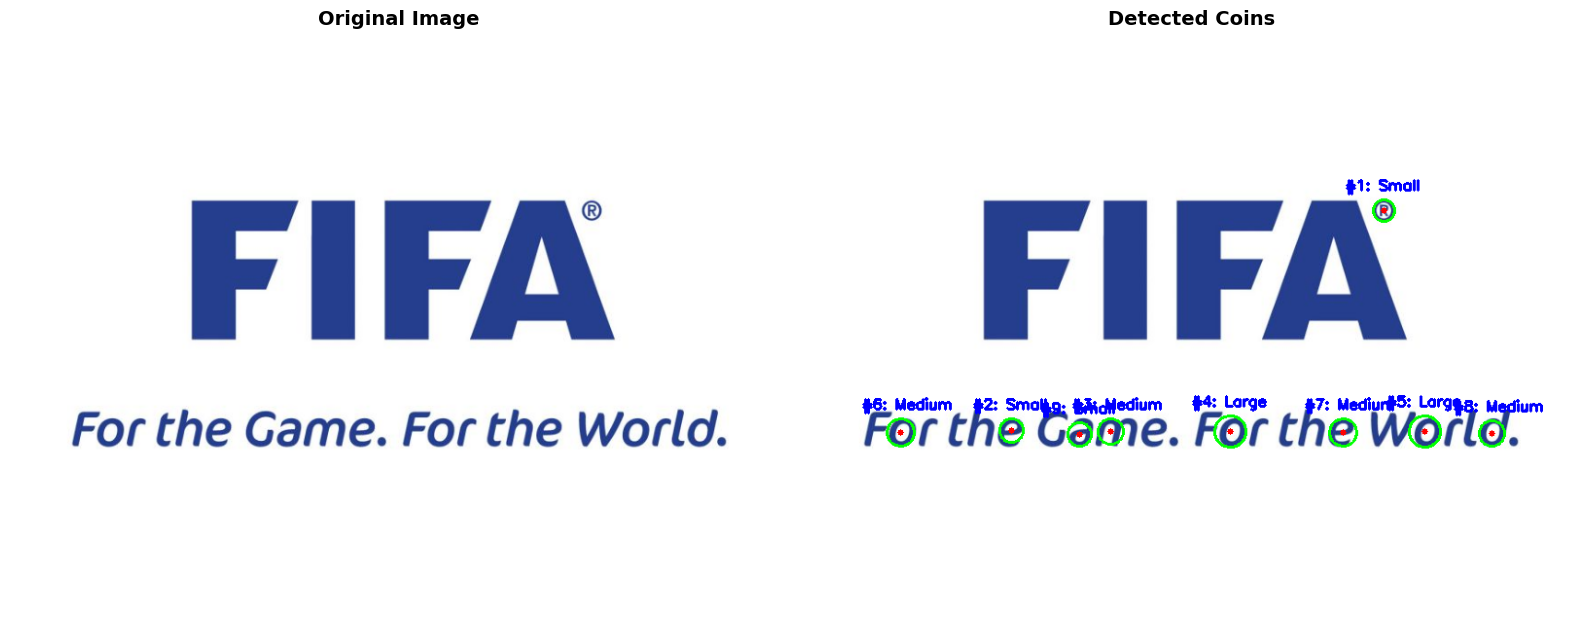

In [152]:
# Change this to your image path
image_file = 'coin_image.jpg'

if os.path.exists(image_file):
    coins = analyze_coins(image_file)
else:
    print(f"Image not found: {image_file}")
    print("\nProvide a coin image and update the 'image_file' variable above.")